In [1]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib


In [2]:
from LFBOT_config import *

In [3]:
#import paths
db_dir, base_dir = get_user_config("shar")

[CONFIG] Using Shar's Darwin setup


In [4]:
#import metric and shared utils
metric, shared_utils = get_metric_and_su() #if this gives a UserWarning, run it again to clear

/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loaded metric module: LFBOT_metric
[INFO] Loaded shared_utils module


In [5]:
#scientifically correct metric variables values live in MDwarf_config.py file and have been imported
#but you can adjust them here if you want to run tests

#adjusting rate density to be more manageable
rate_density = rate_density / 100



# Standardized output paths for this science case
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="LFBOTs", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        use_kcorrect=use_kcorrect,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths


LFBOTs_den_4.2e-09_d_None-None_Mpc_z_0.00226-3_ext_True_kcor_True_None


In [6]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Loading light curve templates from /lustre/lrspec/metrics/results/LFBOTs/LFBOTs_den_4.2e-09_d_None-None_Mpc_z_0.00226-3_ext_True_kcor_True_None_templates.pkl.
Loaded LFBOT templates from /lustre/lrspec/metrics/results/LFBOTs/LFBOTs_den_4.2e-09_d_None-None_Mpc_z_0.00226-3_ext_True_kcor_True_None_templates.pkl


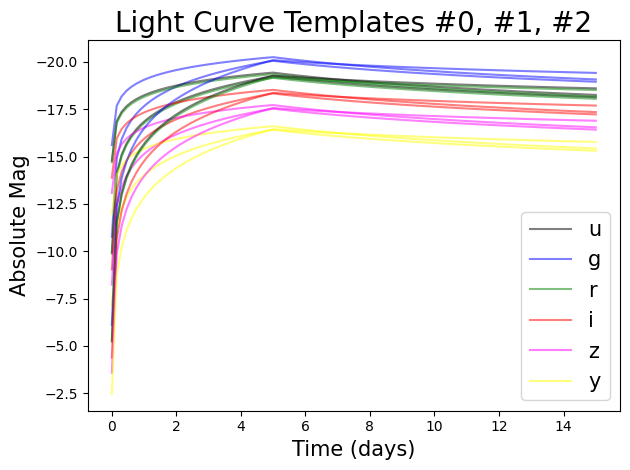

In [7]:
#plot light curves from pkl file if desired
shared_utils.plot_template_lcs(templates_file, num=3, use_log_time=False, plot_overlap=True)

In [8]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    lc_model=shared_lc_model,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=num_lightcurves, #technically should read this from the file
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg,
)


[INFO] Loading population from /lustre/lrspec/metrics/results/LFBOTs/LFBOTs_den_4.2e-09_d_None-None_Mpc_z_0.00226-3_ext_True_kcor_True_None_population.pkl
Loaded population from /lustre/lrspec/metrics/results/LFBOTs/LFBOTs_den_4.2e-09_d_None-None_Mpc_z_0.00226-3_ext_True_kcor_True_None_population.pkl


## All 10 years


--- Running four_roll_v5.0.0_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 784
mag_obs         | type: <class 'list'> | length: 784
snr_obs         | type: <class 'list'> | length: 784
filter          | type: <class 'list'> | length: 784
diag_sample_mjd | type: <class 'list'> | length: 9
diag_sample_mag | type: <class 'list'> | length: 9
diag_sample_snr | type: <class 'list'> | length: 9
diag_sample_filter | type: <class 'list'> | length: 9
per_filter_min_mag | type: <class 'dict'> | length: 6
max_flux_change_sigma | type: <class 'dict'> | length: 6
any_flux_change_gt3 | type: <class 'bool'> | value: False
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 453
ra              | type: <class 'numpy.float64'> 

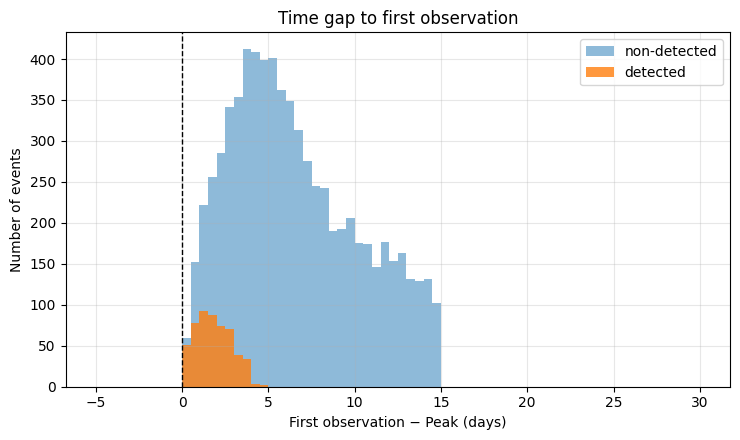

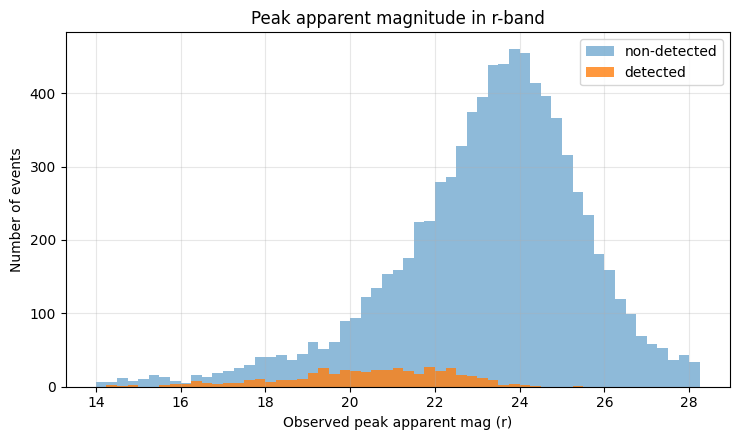

KeyboardInterrupt: 

In [9]:
#run detection metric
df_obs = shared_utils.run_detect(metric, 
                                 slicer, 
                                 cadences, 
                                 shared_lc_model, 
                                 db_dir, storage_dir, 
                                 df_file, 
                                 ignore_triples=ignore_triples, 
                                 debug=True, plot=True, 
                                 clean_temp=clean_temp,
                                 use_kcorrect=use_kcorrect,
                                 k_correct_type=k_correct_type,
                                 k_correct_arg=k_correct_arg,
                                 use_extinction=use_extinction)



In [36]:
importlib.reload(metric)

<module 'local_LFBOTmetric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/LFBOT/local_LFBOTmetric.py'>

In [31]:
color_ok

False

In [247]:
cols = ["sid",
        "injected_peak_ebv_mag_r",
        "injected_peak_ebv_mag_r_cadence",
        "eval_peak_mag"]
print(df_obs[cols].head())

print("Residuals vs cadence-aware (should ~0):",
      np.nanmedian(df_obs["eval_peak_mag"] - df_obs["injected_peak_ebv_mag_r_cadence"]))

print("Cadence penalty (cadence − global):",
      np.nanmedian(df_obs["injected_peak_ebv_mag_r_cadence"] - df_obs["injected_peak_ebv_mag_r"]))


   sid  injected_peak_ebv_mag_r  injected_peak_ebv_mag_r_cadence  \
0    1                18.391526                              NaN   
1    2                20.609923                        21.619325   
2    3                21.176206                              NaN   
3    4                15.729507                        17.059811   
4    5                20.332252                        22.316902   

   eval_peak_mag  
0            NaN  
1      21.619325  
2      22.826753  
3      17.048027  
4      22.316902  
Residuals vs cadence-aware (should ~0): -0.3571463181309582
Cadence penalty (cadence − global): 1.407833485858541


In [50]:

#choose what to run in run_multi_metrics
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['detect'], use_extinction=use_extinction, use_kcorrect=use_kcorrect, k_correct_type=k_correct_type, k_correct_arg=k_correct_arg)


# Apply consistent diagnostics knobs
for m in multi_metrics:
    m.diag_store = False
    m.diag_sample_rate = 0.01
    m.diag_per_event_cap = 30
    m.diag_min_snr = 3
    m.diag_max_mag = None




--- Running four_roll_v5.0.0_10yrs ---
(1,)
                                        Sum                     run  \
four_roll_v5.0.0_10yrs_Detect_Metric  530.0  four_roll_v5.0.0_10yrs   

                                      n_events_full_sky  
four_roll_v5.0.0_10yrs_Detect_Metric              48364  


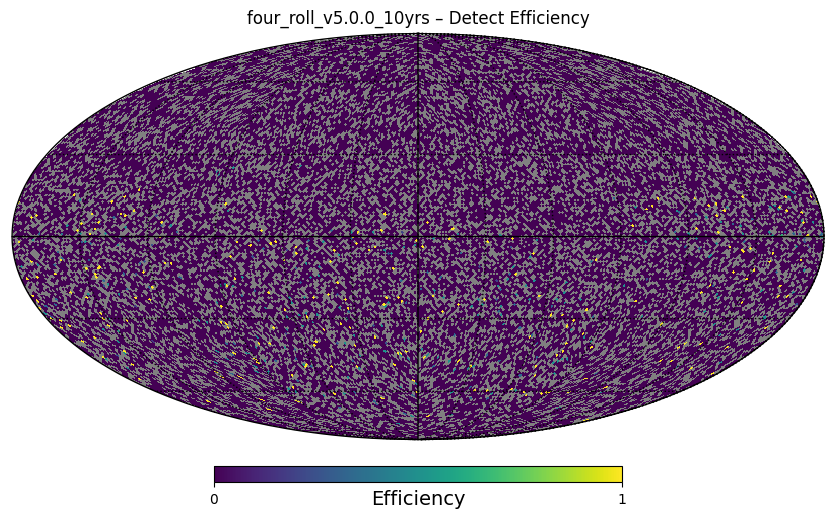

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v5.0.0_10yrs ---
(1,)


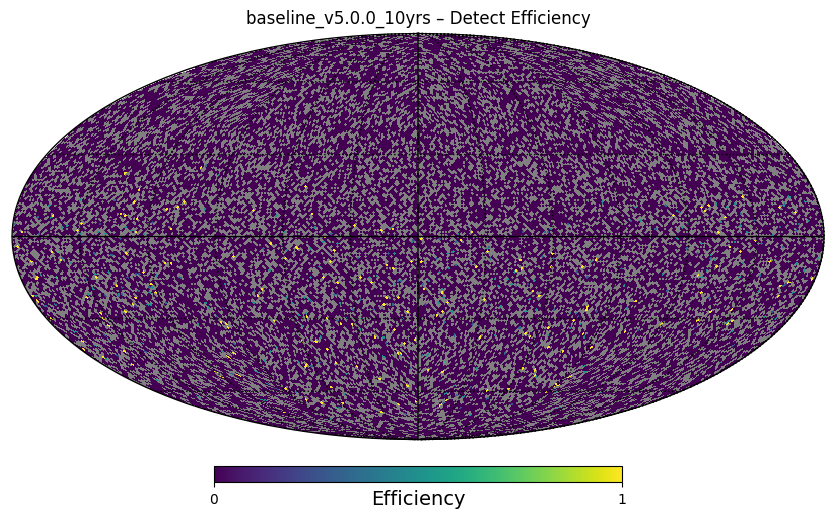

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v3.6_10yrs

--- Running noroll_v3.6_10yrs ---
(1,)


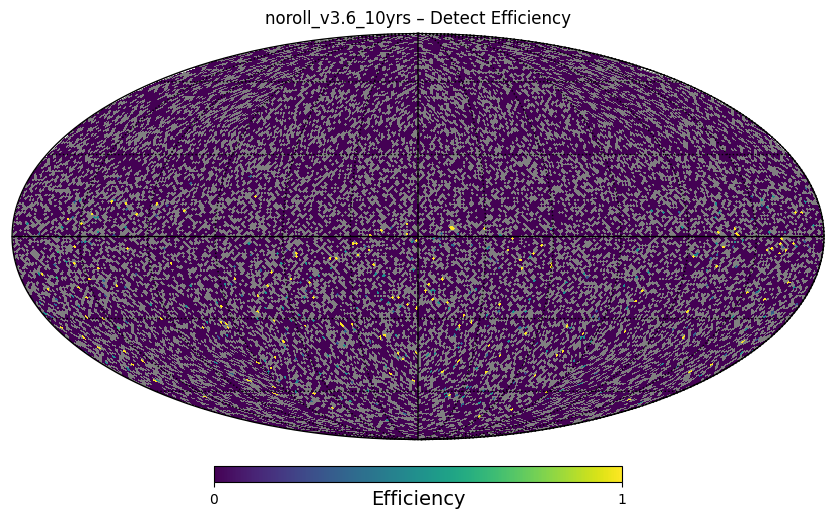

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v3.6_10yrs ---
(1,)


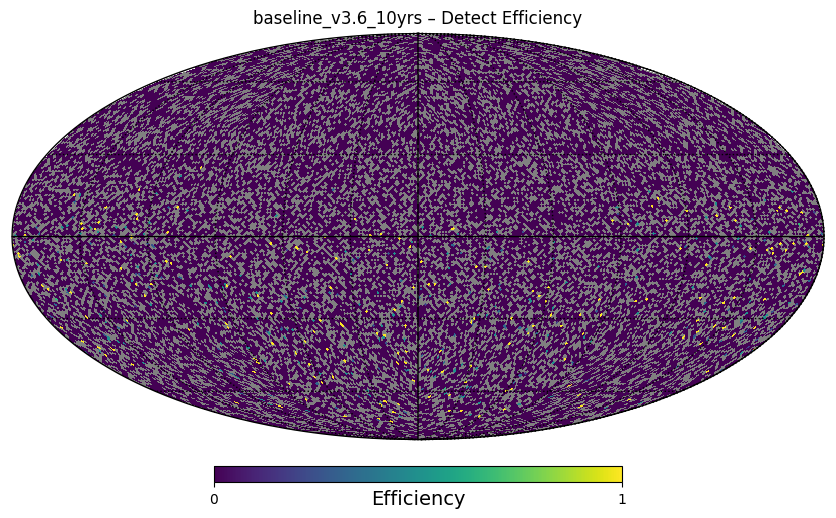

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v3.6_10yrs
saved summary to  /lustre/lrspec/metrics/results/LFBOTs/LFBOTs_den_4.2e-09_d_None-None_Mpc_z_0.00226-3_ext_True_kcor_True_None_None_multi_summary.csv


In [51]:
summary_df_new = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [52]:
#divided by 100
summary_df_new

,Sum,run,n_events_full_sky
four_roll_v5.0.0_10yrs_Detect_Metric,530.0,four_roll_v5.0.0_10yrs,48364
baseline_v5.0.0_10yrs_Detect_Metric,487.0,baseline_v5.0.0_10yrs,48364
noroll_v3.6_10yrs_Detect_Metric,426.0,noroll_v3.6_10yrs,48364
baseline_v3.6_10yrs_Detect_Metric,480.0,baseline_v3.6_10yrs,48364



--- Running four_roll_v4.3.1_10yrs ---
(2,)
[<local_LFBOTmetric.Detect_Metric object at 0x4bce413d0>, <local_LFBOTmetric.LFBOTCharacterizeMetric object at 0x4bce41ed0>]
                                         Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  4276.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric              32655  
[DEBUG] Detected RA, Dec: 6.33, 3.58
[DEBUG] Detected RA, Dec: 53.00, -56.64
[DEBUG] Detected RA, Dec: 79.45, -24.62


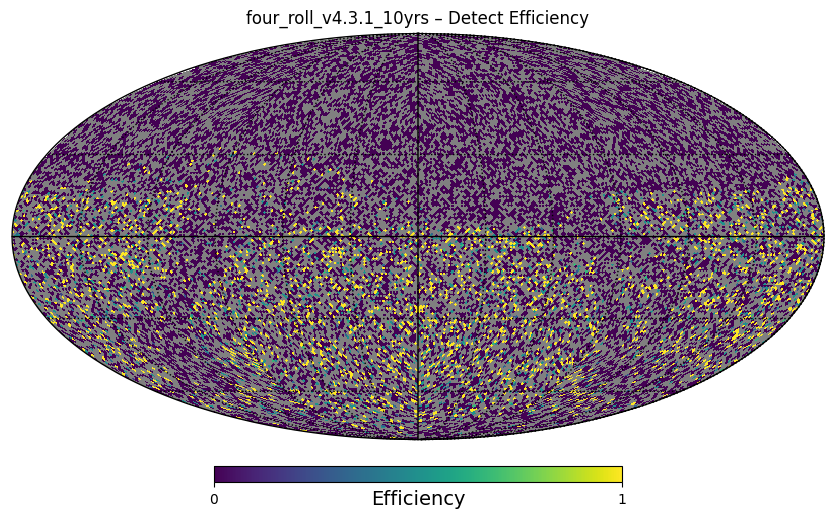

[DEBUG] Detected RA, Dec: 277.79, -51.26
[DEBUG] Detected RA, Dec: 357.19, 7.78
[DEBUG] Detected RA, Dec: 122.62, -60.43
[DEBUG] Detected RA, Dec: 315.00, -33.51
[DEBUG] Detected RA, Dec: 67.50, -29.31
[DEBUG] Detected RA, Dec: 92.65, -77.55
[DEBUG] Detected RA, Dec: 97.73, -1.19
[DEBUG] Detected RA, Dec: 84.38, 8.99
[DEBUG] Detected RA, Dec: 136.41, 6.58
[DEBUG] Detected RA, Dec: 119.21, -47.36
[DEBUG] Detected RA, Dec: 5.77, -61.19
[DEBUG] Detected RA, Dec: 169.74, -47.36


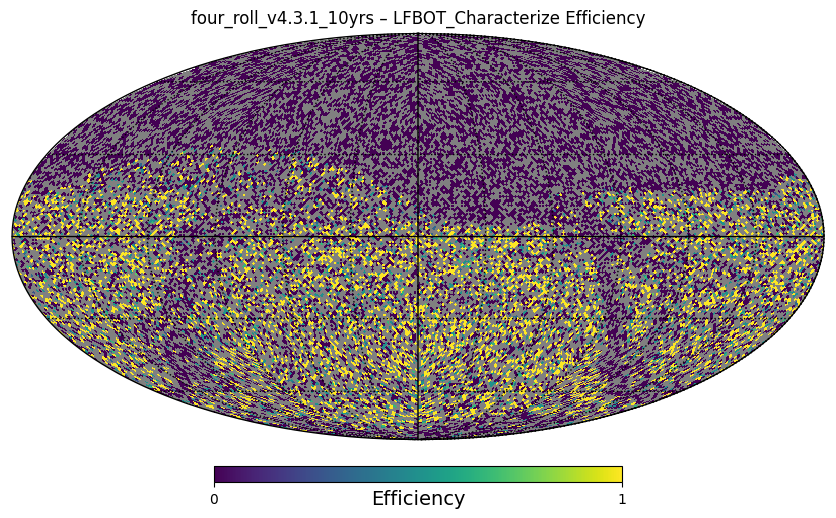

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/Metric_temp_four_roll_v4.3.1_10yrs
saved summary to  /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_ext_True_kcor_True_None_None_multi_summary.csv


In [249]:
summary_df_1 = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [250]:
summary_df_1

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,4276.0,four_roll_v4.3.1_10yrs,32655
four_roll_v4.3.1_10yrs_LFBOTCharacterizeMetric,8604.0,four_roll_v4.3.1_10yrs,32655


In [251]:
import pickle
with open(pop_file, 'rb') as f:
    sp = pickle.load(f)
missing = [f'peak_app_mag_ebv_{f}' for f in ('u','g','r','i','z','y') if f'peak_app_mag_ebv_{f}' not in sp]
print("Missing peak columns:", missing or "None — all present")


Missing peak columns: None — all present


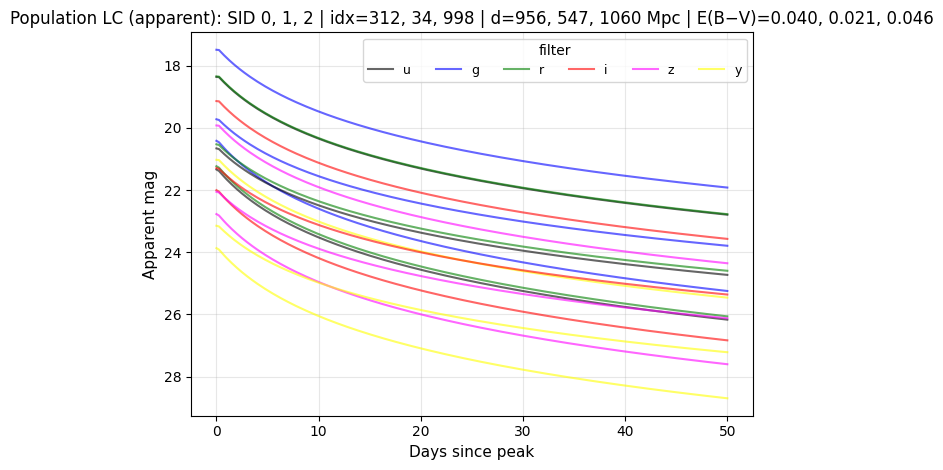

In [252]:
shared_utils.plot_population_lcs(
    pop_file=pop_file,
    lc_model=shared_lc_model,   # or pass templates_file=templates_file
    fast_peaks=False,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg,
    num=3,
    days_before=0.0,            # see note below
    days_after=100.0,
    use_log_time=False,
    overlap=True
)
